   number_courses  time_study   Marks  StudyTime(Hours)  StudyTime(Mins)
0               3       4.508  19.202                 4              240
1               4       0.096   7.734                 0                0
2               4       3.133  13.811                 3              180
3               6       7.909  49.018                 7              420
4               8       7.811  45.299                 7              420 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   number_courses    100 non-null    int64  
 1   time_study        100 non-null    float64
 2   Marks             100 non-null    float64
 3   StudyTime(Hours)  100 non-null    int64  
 4   StudyTime(Mins)   100 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 4.0 KB
None 

       number_courses  time_study       Marks  StudyTime(Hours)  \
coun

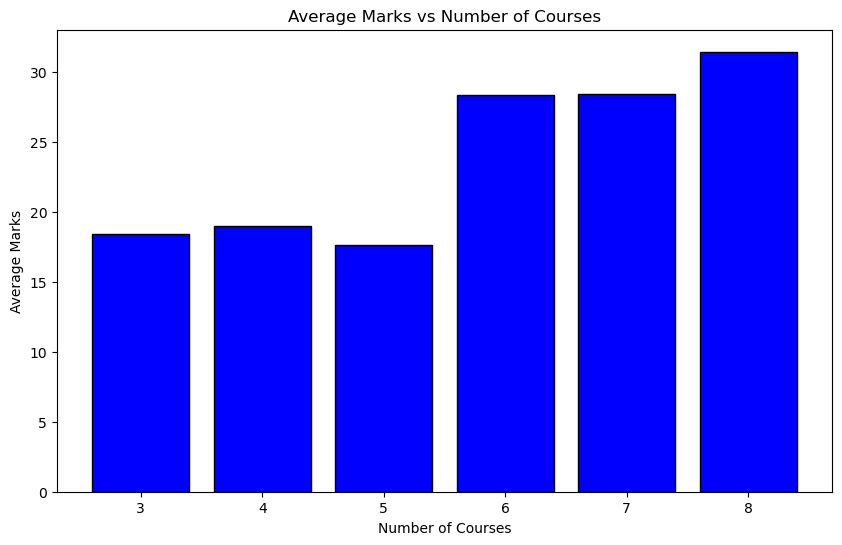

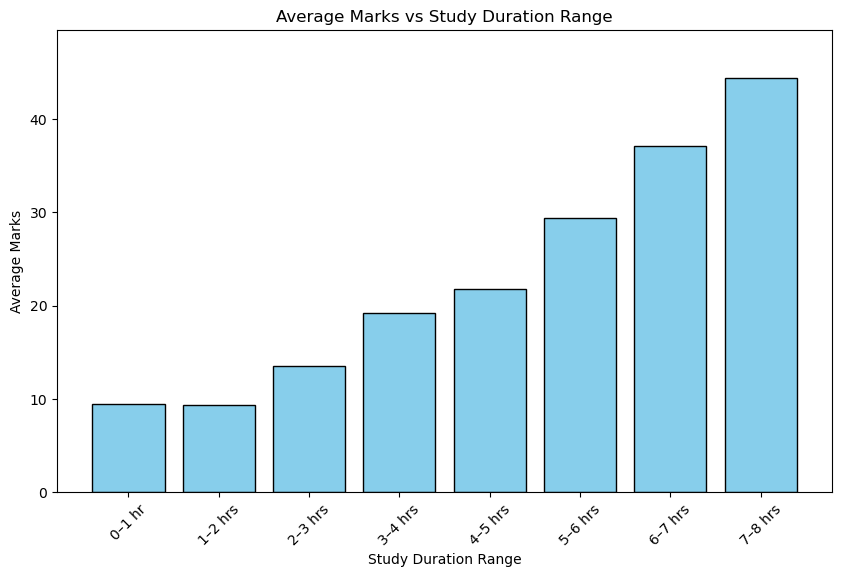

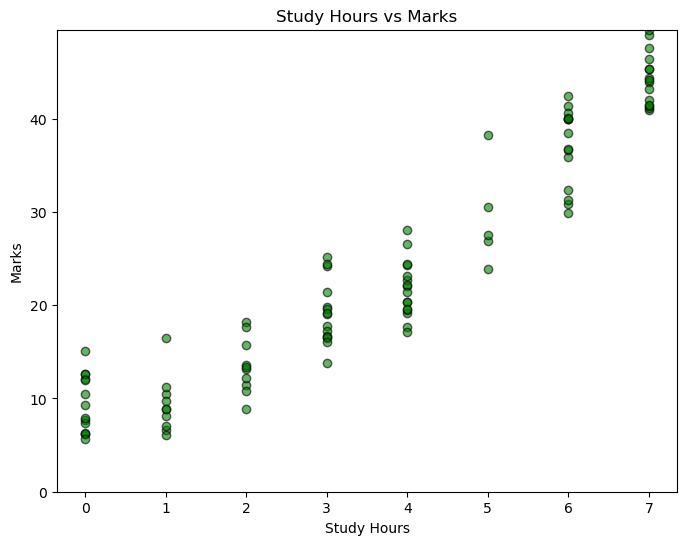

📊 Model Evaluation:
R² Score: 0.9587
✅ The model explains most of the variation — excellent accuracy.
Mean Absolute Error (MAE): 2.27
👍 Acceptable error range, but can be improved.
Root Mean Squared Error (RMSE): 2.74
👍 Errors are reasonable — model is fairly good.


Enter study time (in hours):  6
Enter number of courses:  4


Predicted Marks: 33.45



In [ ]:
# ===== 1. Import Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ===== 2. Load Dataset =====
df = pd.read_csv("Student_Marks.csv")

# Show dataset info
print(df.head(), "\n")
print(df.info(), "\n")
print(df.describe(), "\n")
print("Missing values:\n", df.isnull().sum(), "\n")

# ===== 3. Visualization: No. of Courses vs Marks =====
courses_group = df.groupby("number_courses")['Marks'].mean()
plt.figure(figsize=(10, 6))
plt.bar(courses_group.index, courses_group.values, color="blue", edgecolor='black')
plt.xlabel("Number of Courses")
plt.ylabel("Average Marks")
plt.title("Average Marks vs Number of Courses")
plt.show()

# ===== 4. Visualization: Study Duration Range vs Marks =====
bins = [0, 60, 120, 180, 240, 300, 360, 420, 480]
labels = ['0–1 hr', '1–2 hrs', '2–3 hrs', '3–4 hrs', '4–5 hrs', '5–6 hrs', '6–7 hrs', '7–8 hrs']
df['duration_range'] = pd.cut(df['StudyTime(Mins)'], bins=bins, labels=labels, right=False)

grouped = df.groupby('duration_range', observed=True)['Marks'].mean()
plt.figure(figsize=(10, 6))
plt.bar(grouped.index.astype(str), grouped.values, color='skyblue', edgecolor='black')
plt.xlabel("Study Duration Range")
plt.ylabel("Average Marks")
plt.title("Average Marks vs Study Duration Range")
plt.xticks(rotation=45)
plt.ylim(0, df['Marks'].max())
plt.show()

# ===== 5. Scatter Plot: Study Hours vs Marks =====
plt.figure(figsize=(8, 6))
plt.scatter(df['StudyTime(Hours)'], df['Marks'], alpha=0.6, color='green', edgecolor='black')
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.ylim(0, df['Marks'].max())
plt.show()

# ===== 6. Model Training =====
X = df[['StudyTime(Hours)', 'number_courses']].values
Y = df['Marks'].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

# ===== 7. Model Evaluation =====
Y_pred = model.predict(X_test)

r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("📊 Model Evaluation:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}\n")

# ===== 8. Prediction from User Input =====
while True:
    try:
        study_time = float(input("Enter study time (in hours): "))
        num_courses = int(input("Enter number of courses: "))
        
        prediction = model.predict([[study_time, num_courses]])
        print(f"Predicted Marks: {prediction[0]:.2f}\n")
        
        cont = input("Do you want to predict again? (y/n): ").strip().lower()
        if cont != 'y':
            break
    except ValueError:
        print("❌ Please enter valid numeric values.\n")
